# Phase 5: Saliency Metrics

This notebook runs the quantitative part of the stress test.

It compares saliency maps computed on:

- original images;
- images with approximate background perturbations.

Metrics:

- IoU between the top 20% most salient pixels;
- Spearman rank correlation between flattened saliency maps;
- confidence delta;
- prediction change flag.

In [13]:
from pathlib import Path
from IPython.display import Image, display
import csv
import subprocess
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CANDIDATE_MANIFESTS = [
    PROJECT_ROOT / "data" / "AWA2_subset_background20" / "awa2_manifest_subset.csv",
    PROJECT_ROOT / "data" / "AWA2" / "awa2_manifest_debug.csv",
    PROJECT_ROOT / "data" / "AWA2" / "awa2_manifest.csv",
]
MANIFEST = next((path for path in CANDIDATE_MANIFESTS if path.exists()), None)
if MANIFEST is None:
    raise FileNotFoundError("No AwA2 manifest found.")

CHECKPOINT = PROJECT_ROOT / "outputs" / "checkpoints" / "best_resnet50_awa2.pt"
CSV_OUTPUT = PROJECT_ROOT / "outputs" / "reports" / "phase5_saliency_metrics_notebook.csv"
FIGURE_OUTPUT = PROJECT_ROOT / "outputs" / "figures" / "phase5_saliency_comparison_notebook.png"

MAX_IMAGES = 4
XAI_METHODS = ["gradcam", "integrated_gradients"]
IG_STEPS = 16
TOP_PERCENT = 20
MASK_STRATEGY = "center_ellipse"
FOREGROUND_SCALE = 0.68
ALLOW_INCORRECT = False

print("manifest:", MANIFEST)
print("checkpoint:", CHECKPOINT)
print("checkpoint_exists:", CHECKPOINT.exists())
print("csv_output:", CSV_OUTPUT)
print("figure_output:", FIGURE_OUTPUT)

manifest: /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2_subset_background20/awa2_manifest_subset.csv
checkpoint: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/checkpoints/best_resnet50_awa2.pt
checkpoint_exists: True
csv_output: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase5_saliency_metrics_notebook.csv
figure_output: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase5_saliency_comparison_notebook.png


## Run Phase 5

For speed, use only `gradcam` first. Add `integrated_gradients` when the pipeline is working and you have enough GPU time.

In [14]:
cmd = [
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "run_phase5_metrics.py"),
    "--manifest", str(MANIFEST),
    "--checkpoint", str(CHECKPOINT),
    "--csv-output", str(CSV_OUTPUT),
    "--figure-output", str(FIGURE_OUTPUT),
    "--max-images", str(MAX_IMAGES),
    "--ig-steps", str(IG_STEPS),
    "--top-percent", str(TOP_PERCENT),
    "--mask-strategy", MASK_STRATEGY,
    "--foreground-scale", str(FOREGROUND_SCALE),
    "--xai-methods", *XAI_METHODS,
]
if ALLOW_INCORRECT:
    cmd.append("--allow-incorrect")

print(" ".join(cmd))
completed = subprocess.run(cmd, cwd=PROJECT_ROOT, text=True, capture_output=True)
print(completed.stdout)
print(completed.stderr)
if completed.returncode != 0:
    raise RuntimeError(f"Phase 5 failed with exit code {completed.returncode}")

/home/emma/DeepLearning/.venvDeepLearning/bin/python /home/emma/DeepLearning/Deep_Learning_XAI/scripts/run_phase5_metrics.py --manifest /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2_subset_background20/awa2_manifest_subset.csv --checkpoint /home/emma/DeepLearning/Deep_Learning_XAI/outputs/checkpoints/best_resnet50_awa2.pt --csv-output /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase5_saliency_metrics_notebook.csv --figure-output /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase5_saliency_comparison_notebook.png --max-images 4 --ig-steps 16 --top-percent 20 --mask-strategy center_ellipse --foreground-scale 0.68 --xai-methods gradcam integrated_gradients

2026-07-06 16:40:44 | INFO | src.data | Loaded AwA2 split=train with 2782 samples, 20 visible classes and 20 mapped classes
2026-07-06 16:40:44 | INFO | src.data | Loaded AwA2 split=val with 596 samples, 20 visible classes and 20 mapped classes
2026-07-06 16:40:44 | INFO | src.data | Loaded AwA2 split=

## Inspect CSV Metrics Intuitively

The CSV contains one row for each combination of image, XAI method, and perturbation. Instead of reading raw rows, we convert the file into three questions:

- **Did the prediction change?** This tells us whether the perturbation changed the model decision.
- **Did the confidence drop?** This tells us whether the model became less certain after the background changed.
- **Did the saliency map move?** Low IoU or low Spearman means the explanation is unstable even if the prediction is unchanged.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

if not CSV_OUTPUT.exists():
    raise FileNotFoundError(CSV_OUTPUT)

metrics = pd.read_csv(CSV_OUTPUT)
iou_col = next(column for column in metrics.columns if column.startswith("iou_top_"))

numeric_cols = ["original_confidence", "perturbed_confidence", "confidence_delta", iou_col, "spearman"]
for column in numeric_cols:
    metrics[column] = pd.to_numeric(metrics[column], errors="coerce")

if metrics["prediction_changed"].dtype == object:
    metrics["prediction_changed"] = metrics["prediction_changed"].astype(str).str.lower().eq("true")

# The script column confidence_delta is perturbed - original.
# For interpretation, confidence_drop is more intuitive: positive means the model lost confidence.
metrics["confidence_drop"] = metrics["original_confidence"] - metrics["perturbed_confidence"]
metrics["saliency_drift"] = (1.0 - metrics[iou_col]) + (1.0 - metrics["spearman"]) / 2.0
metrics["prediction_transition"] = (
    metrics["original_prediction"].astype(str)
    + " -> "
    + metrics["perturbed_prediction"].astype(str)
)
metrics["case"] = (
    metrics["true_class"].astype(str)
    + " | "
    + metrics["prediction_transition"].astype(str)
    + " | "
    + metrics["perturbation"].astype(str)
    + " | "
    + metrics["xai_method"].astype(str)
)

print("rows:", len(metrics))
print("unique image indices:", metrics["index"].nunique())
print("xai methods:", sorted(metrics["xai_method"].unique()))
print("perturbations:", sorted(metrics["perturbation"].unique()))
print("prediction change rate:", round(metrics["prediction_changed"].mean(), 3))
metrics.head()


rows: 24
unique image indices: 4
xai methods: ['gradcam', 'integrated_gradients']
perturbations: ['background_swap', 'color_shift', 'gaussian_noise']
prediction change rate: 0.25


,index,true_class,target_class_for_saliency,xai_method,perturbation,original_prediction,perturbed_prediction,prediction_changed,original_confidence,perturbed_confidence,confidence_delta,iou_top_20pct,spearman,confidence_drop,saliency_drift,prediction_transition,case
0,0,antelope,antelope,gradcam,gaussian_noise,antelope,antelope,False,0.947785,0.981859,0.034074,0.831238,0.950985,-0.034074,0.193270,antelope -> antelope,antelope | antelope -> antelope | gaussian_noi...
1,1,antelope,antelope,gradcam,gaussian_noise,antelope,antelope,False,0.996936,0.989617,-0.007318,0.710485,0.956115,0.007318,0.311457,antelope -> antelope,antelope | antelope -> antelope | gaussian_noi...
2,2,antelope,antelope,gradcam,gaussian_noise,antelope,antelope,False,0.975330,0.991456,0.016127,0.892321,0.930308,-0.016127,0.142525,antelope -> antelope,antelope | antelope -> antelope | gaussian_noi...
3,3,antelope,antelope,gradcam,gaussian_noise,antelope,antelope,False,0.945896,0.918123,-0.027772,0.546484,0.861832,0.027772,0.522600,antelope -> antelope,antelope | antelope -> antelope | gaussian_noi...
4,0,antelope,antelope,gradcam,color_shift,antelope,antelope,False,0.947785,0.739813,-0.207973,0.804019,0.967019,0.207973,0.212472,antelope -> antelope,antelope | antelope -> antelope | color_shift ...


### Summary by XAI Method and Perturbation

Read this table as the experimental answer in compact form. The most suspicious cases have **low IoU**, **low Spearman**, and **positive confidence drop**.


In [16]:
summary = (
    metrics.groupby(["xai_method", "perturbation"], as_index=False)
    .agg(
        examples=("index", "count"),
        prediction_change_rate=("prediction_changed", "mean"),
        mean_confidence_drop=("confidence_drop", "mean"),
        mean_iou=(iou_col, "mean"),
        std_iou=(iou_col, "std"),
        mean_spearman=("spearman", "mean"),
        std_spearman=("spearman", "std"),
        mean_saliency_drift=("saliency_drift", "mean"),
    )
    .sort_values(["mean_saliency_drift", "prediction_change_rate"], ascending=False)
)

summary.style.format({
    "prediction_change_rate": "{:.2%}",
    "mean_confidence_drop": "{:.3f}",
    "mean_iou": "{:.3f}",
    "std_iou": "{:.3f}",
    "mean_spearman": "{:.3f}",
    "std_spearman": "{:.3f}",
    "mean_saliency_drift": "{:.3f}",
}).background_gradient(subset=["mean_saliency_drift"], cmap="YlOrRd")


,xai_method,perturbation,examples,prediction_change_rate,mean_confidence_drop,mean_iou,std_iou,mean_spearman,std_spearman,mean_saliency_drift
3,integrated_gradients,background_swap,4,50.00%,0.519,0.227,0.015,0.195,0.064,1.175
4,integrated_gradients,color_shift,4,25.00%,0.265,0.224,0.027,0.212,0.096,1.170
5,integrated_gradients,gaussian_noise,4,0.00%,-0.004,0.255,0.019,0.305,0.063,1.093
0,gradcam,background_swap,4,50.00%,0.519,0.445,0.324,0.420,0.621,0.845
1,gradcam,color_shift,4,25.00%,0.265,0.537,0.312,0.622,0.629,0.652
2,gradcam,gaussian_noise,4,0.00%,-0.004,0.745,0.152,0.925,0.043,0.292


### Which Animal Appears After Perturbation?

This table makes the failure mode explicit: for each perturbation, it shows the animal predicted after the background was changed. The key column is `prediction_transition`, for example `antelope -> horse`.


In [17]:
transition_summary = (
    metrics.groupby([
        "xai_method",
        "perturbation",
        "true_class",
        "original_prediction",
        "perturbed_prediction",
        "prediction_transition",
    ], as_index=False)
    .agg(
        rows=("index", "count"),
        prediction_changed=("prediction_changed", "max"),
        mean_confidence_drop=("confidence_drop", "mean"),
        mean_saliency_drift=("saliency_drift", "mean"),
    )
    .sort_values(["prediction_changed", "rows", "mean_saliency_drift"], ascending=[False, False, False])
)

transition_summary.style.format({
    "mean_confidence_drop": "{:.3f}",
    "mean_saliency_drift": "{:.3f}",
}).background_gradient(subset=["mean_saliency_drift"], cmap="YlOrRd")


,xai_method,perturbation,true_class,original_prediction,perturbed_prediction,prediction_transition,rows,prediction_changed,mean_confidence_drop,mean_saliency_drift
4,gradcam,color_shift,antelope,antelope,hippopotamus,antelope -> hippopotamus,1,True,0.401,1.573
1,gradcam,background_swap,antelope,antelope,seal,antelope -> seal,1,True,0.601,1.494
2,gradcam,background_swap,antelope,antelope,walrus,antelope -> walrus,1,True,0.760,1.284
7,integrated_gradients,background_swap,antelope,antelope,seal,antelope -> seal,1,True,0.601,1.154
8,integrated_gradients,background_swap,antelope,antelope,walrus,antelope -> walrus,1,True,0.760,1.129
10,integrated_gradients,color_shift,antelope,antelope,hippopotamus,antelope -> hippopotamus,1,True,0.401,1.058
11,integrated_gradients,gaussian_noise,antelope,antelope,antelope,antelope -> antelope,4,False,-0.004,1.093
5,gradcam,gaussian_noise,antelope,antelope,antelope,antelope -> antelope,4,False,-0.004,0.292
9,integrated_gradients,color_shift,antelope,antelope,antelope,antelope -> antelope,3,False,0.220,1.207
3,gradcam,color_shift,antelope,antelope,antelope,antelope -> antelope,3,False,0.220,0.345


### Visual Inspection of the Metrics

- **High IoU** means the top 20% salient region stayed in roughly the same place.
- **High Spearman** means the full pixel ranking stayed similar.
- **Positive confidence drop** means the model became less confident after background perturbation.


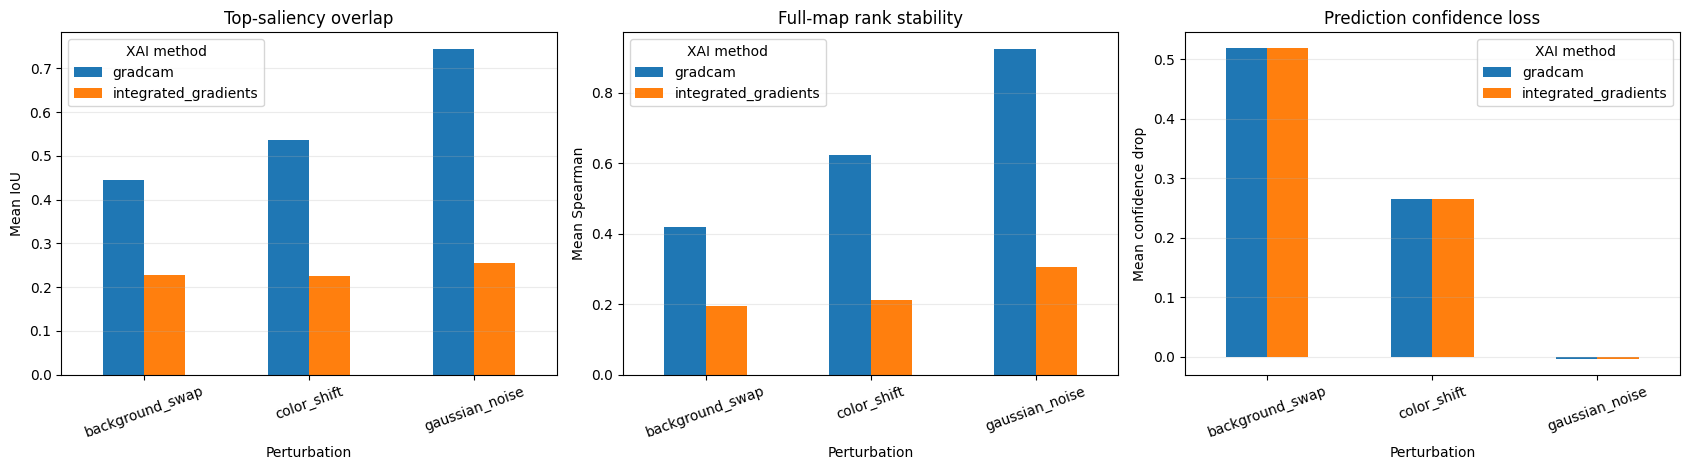

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

for ax, value, title, ylabel in [
    (axes[0], "mean_iou", "Top-saliency overlap", "Mean IoU"),
    (axes[1], "mean_spearman", "Full-map rank stability", "Mean Spearman"),
    (axes[2], "mean_confidence_drop", "Prediction confidence loss", "Mean confidence drop"),
]:
    pivot = summary.pivot(index="perturbation", columns="xai_method", values=value)
    pivot.plot(kind="bar", ax=ax, rot=20)
    ax.set_title(title)
    ax.set_xlabel("Perturbation")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="XAI method")

plt.tight_layout()
plt.show()


### IoU vs Spearman: Stable or Unstable Explanations?

The upper-right area is good: the explanation stayed similar. The lower-left area is suspicious: the saliency map changed both in its top support and in its global ranking.


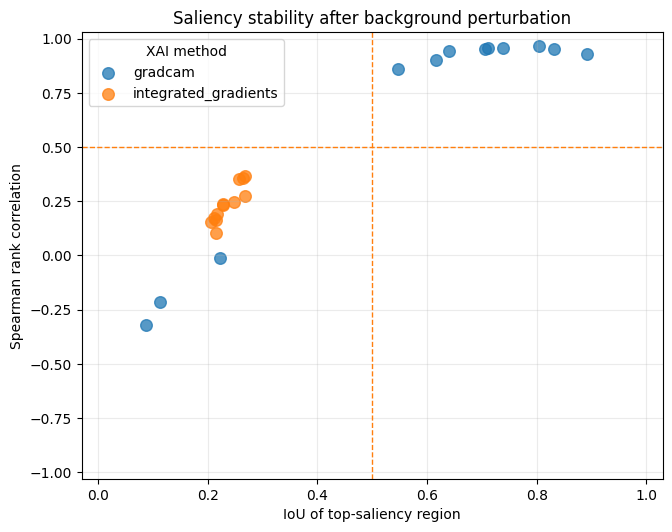

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 5.8))
for method, subset in metrics.groupby("xai_method"):
    ax.scatter(subset[iou_col], subset["spearman"], s=70, alpha=0.75, label=method)

ax.axvline(0.5, color="tab:orange", linestyle="--", linewidth=1)
ax.axhline(0.5, color="tab:orange", linestyle="--", linewidth=1)
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-1.03, 1.03)
ax.set_xlabel("IoU of top-saliency region")
ax.set_ylabel("Spearman rank correlation")
ax.set_title("Saliency stability after background perturbation")
ax.grid(alpha=0.25)
ax.legend(title="XAI method")
plt.show()


### Most Unstable Examples

These rows are the best candidates for the blog post: they show where the explanation moved the most. A high `saliency_drift` means low IoU and/or low Spearman.


In [20]:
most_unstable = metrics.sort_values("saliency_drift", ascending=False).head(12)
display_cols = [
    "true_class",
    "original_prediction",
    "perturbed_prediction",
    "prediction_transition",
    "xai_method",
    "perturbation",
    iou_col,
    "spearman",
    "confidence_drop",
    "saliency_drift",
    "prediction_changed",
]
most_unstable[display_cols].style.format({
    iou_col: "{:.3f}",
    "spearman": "{:.3f}",
    "confidence_drop": "{:.3f}",
    "saliency_drift": "{:.3f}",
}).background_gradient(subset=["saliency_drift"], cmap="YlOrRd")


,true_class,original_prediction,perturbed_prediction,prediction_transition,xai_method,perturbation,iou_top_20pct,spearman,confidence_drop,saliency_drift,prediction_changed
7,antelope,antelope,hippopotamus,antelope -> hippopotamus,gradcam,color_shift,0.087,-0.320,0.401,1.573,True
11,antelope,antelope,seal,antelope -> seal,gradcam,background_swap,0.114,-0.215,0.601,1.494,True
10,antelope,antelope,walrus,antelope -> walrus,gradcam,background_swap,0.222,-0.012,0.760,1.284,True
21,antelope,antelope,antelope,antelope -> antelope,integrated_gradients,background_swap,0.216,0.105,0.699,1.232,False
17,antelope,antelope,antelope,antelope -> antelope,integrated_gradients,color_shift,0.205,0.154,0.032,1.218,False
16,antelope,antelope,antelope,antelope -> antelope,integrated_gradients,color_shift,0.216,0.164,0.208,1.202,False
18,antelope,antelope,antelope,antelope -> antelope,integrated_gradients,color_shift,0.212,0.174,0.420,1.201,False
20,antelope,antelope,antelope,antelope -> antelope,integrated_gradients,background_swap,0.218,0.193,0.016,1.186,False
15,antelope,antelope,antelope,antelope -> antelope,integrated_gradients,gaussian_noise,0.228,0.231,0.028,1.157,False
23,antelope,antelope,seal,antelope -> seal,integrated_gradients,background_swap,0.228,0.236,0.601,1.154,True


### Save the Intuitive Metric Report

This cell saves the aggregated table and the most unstable examples so they can be reused in the HTML blog post.


In [21]:
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
summary_path = REPORT_DIR / "phase5_metric_summary_notebook.csv"
unstable_path = REPORT_DIR / "phase5_most_unstable_examples_notebook.csv"
transitions_path = REPORT_DIR / "phase5_prediction_transitions_notebook.csv"
summary.to_csv(summary_path, index=False)
most_unstable.to_csv(unstable_path, index=False)
transition_summary.to_csv(transitions_path, index=False)
print("saved:", summary_path)
print("saved:", unstable_path)
print("saved:", transitions_path)


saved: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase5_metric_summary_notebook.csv
saved: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase5_most_unstable_examples_notebook.csv
saved: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase5_prediction_transitions_notebook.csv


## Inspect Visual Comparison

The figure uses one saliency method, preferring Grad-CAM when available, and compares original vs perturbed heatmaps.

Each perturbed panel should now show an overlay like `pred after: original_animal -> perturbed_animal`. If you do not see it, rerun the **Run Phase 5** cell above so the PNG is regenerated with the updated plotting code.


visual comparison: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase5_saliency_comparison_notebook.png
If the panels do not show `pred after: original -> perturbed`, rerun the Run Phase 5 cell to regenerate this PNG.


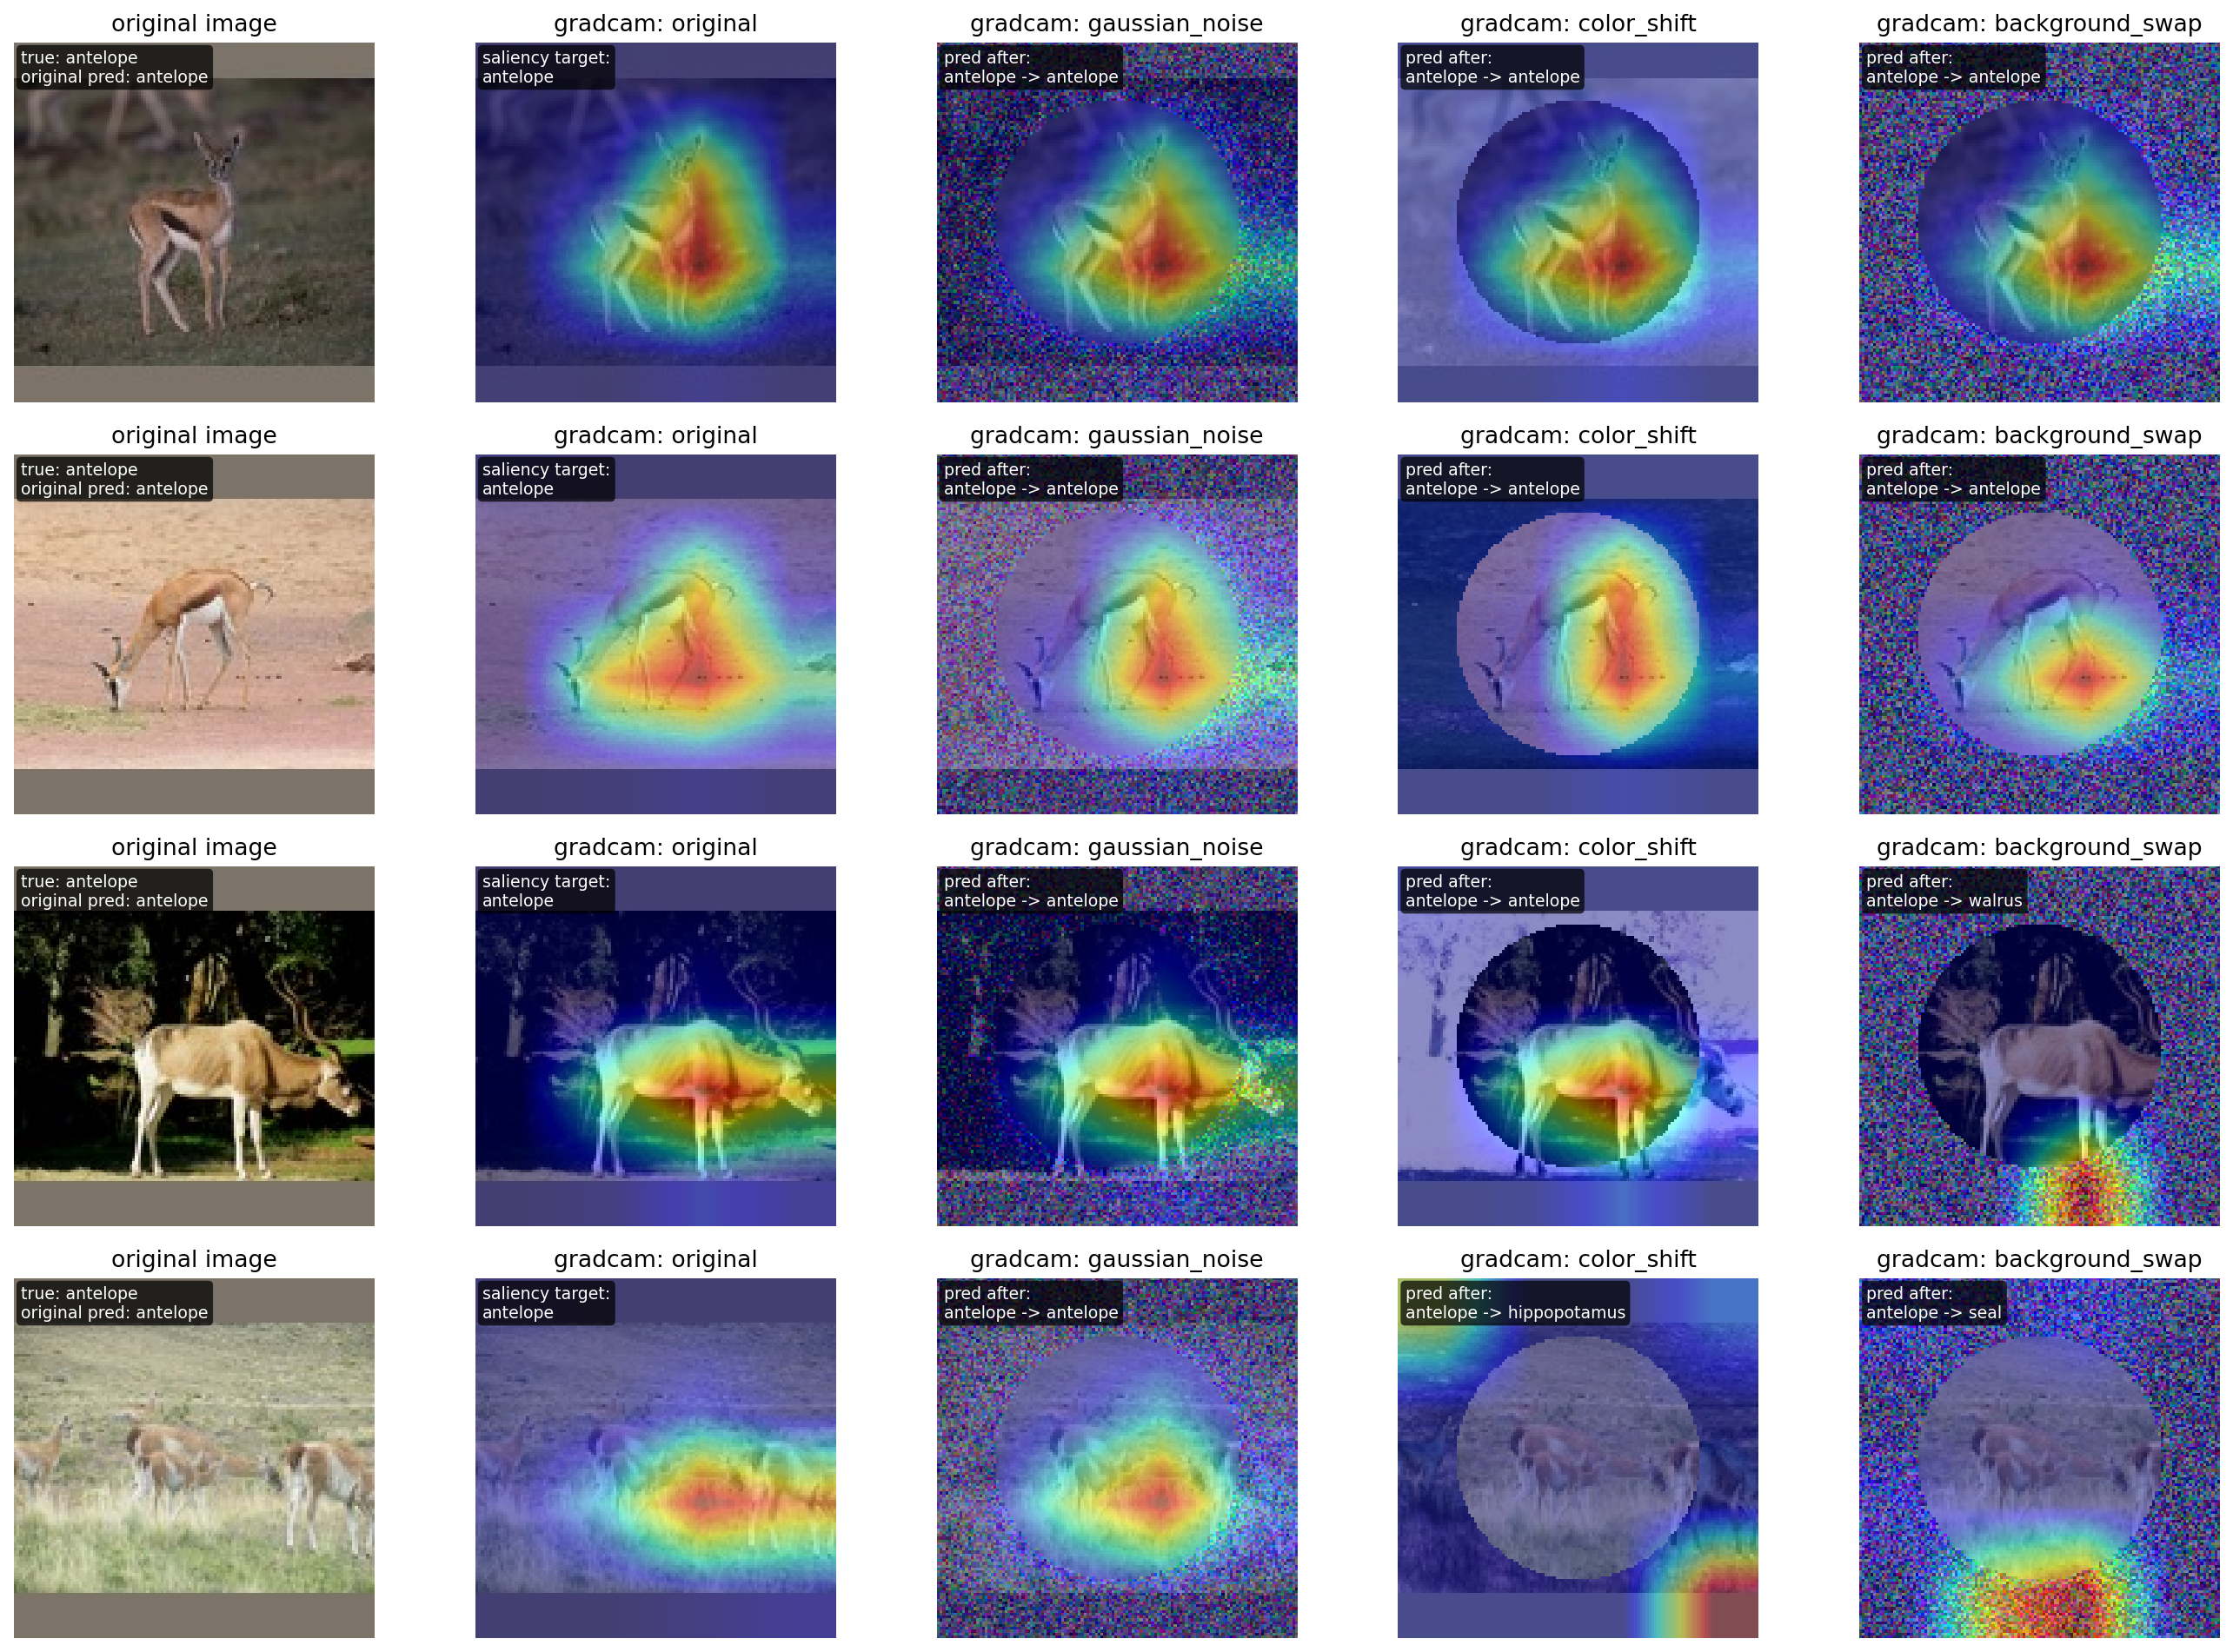

In [22]:
if FIGURE_OUTPUT.exists():
    print("visual comparison:", FIGURE_OUTPUT)
    print("If the panels do not show `pred after: original -> perturbed`, rerun the Run Phase 5 cell to regenerate this PNG.")
    display(Image(filename=str(FIGURE_OUTPUT)))
else:
    print("Figure was not created:", FIGURE_OUTPUT)
